In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from typing import *
from pathlib import Path
import json
import gc
import math

from tqdm import tqdm
import torch
from torch import Tensor, nn

from Bio import Phylo
import numpy as np
import scipy
import pandas as pd
import gem
import matplotlib.pyplot as plt
import seaborn as sb
import sys


from gem.datasets import AbstractMetaphlanPreembeddedDataset, TorchStackedMetaphlanPreembeddedDataset, MetaphlanProfileParser, MetaphlanProfile
from gem.ml import SGBAbundancePredictionModel, SGBAbundanceLayeredPredictionModel, SGBEmbedPoolConcatPredictionModel, safe_kl_div_loss, HierarchicalSetTransformer

# Baseline predictors

In [3]:
class BaselinePredictor:
    def predict_abundances(self, sgb_ids: List[str]) -> np.ndarray:
        raise NotImplementedError()

## Uniform Abundance

In [4]:
""" Class definition. """
class UniformAbundancePredictor(BaselinePredictor):
    def __init__(self):
        pass

    def predict_abundances(self, sgb_ids: List[str]) -> np.ndarray:
        """ Compute output. """
        pred = np.ones(len(sgb_ids), dtype=float)
        pred = pred / np.sum(pred)
        return pred

## nearest-neighbor

### Implementation

In [5]:
""" Class definition. """
class NearestNeighborSGBFinder:
    def __init__(self, matrix_file: Path, database_sgbs: List[str]):
        data = np.load(matrix_file)
        all_sgbs = data['labels']
        dist_mat = data['mat']

        all_sgb_set = set(all_sgbs)
        for sgb_id in database_sgbs:
            if sgb_id not in all_sgb_set:
                print(f"[WARNING] SGB {sgb_id} not found in distance matrix. It probably lacks PhyloPhlAn markers and was excluded from the tree.")
        database_sgbs = [x for x in database_sgbs if x in all_sgb_set]

        all_sgb_indices = {lbl: i for i, lbl in enumerate(all_sgbs)}
        db_sgb_indices = {lbl: i for i, lbl in enumerate(database_sgbs)}

        db_matrix_indices = [all_sgb_indices[lbl] for lbl in database_sgbs]
        self.submatrix = dist_mat[:, db_matrix_indices]
        self.db_sgb_indices = db_sgb_indices
        self.db_sgb_order = database_sgbs
        self.query_sgb_indices = all_sgb_indices

    def __contains__(self, sgb_id: str) -> bool:
        return sgb_id in self.query_sgb_indices

    def nearest_neighbor(self, query_sgb_id: str) -> str:
        assert query_sgb_id in self.query_sgb_indices, f"Query SGB {query_sgb_id} is not in the query set!"
        query_idx = self.query_sgb_indices[query_sgb_id]
        query_row = self.submatrix[query_idx, :]
        nn_idx = np.argmin(query_row)
        return self.db_sgb_order[nn_idx]


def geom_mean_2d_column_nonzero(A: np.ndarray) -> np.ndarray:
    """
    For each column of a 2-d array A, compute the geometric mean of only nonzero entries (of that column).
    """
    mask = A != 0                            # Mask for nonzero entries
    counts = mask.sum(axis=0)                # Count nonzero entries per column
    A_safe = np.where(mask, A, 1)            # To avoid log(0): temporarily replace zeros with 1 (log(1) = 0, and they are masked anyway)
    log_sums = np.log(A_safe).sum(axis=0)    # Sum of logs over nonzero entries per column
    geom_means = np.exp(log_sums / counts)   # Geometric mean = exp( sum(log(x_i)) / count )
    geom_means[counts == 0] = np.nan         # If a column has no nonzero entries, set the geom mean to np.nan
    return geom_means


class NearestNeighborAveragingPredictorInner(BaselinePredictor):
    """
    Predict an abundance by assigning a weight to each SGB in the specified query sample.
    The weight of SGB "X" is equal to the geometric mean of the abundance of NearestNeighbor(X) in the training samples, or possibly the k-nearest training samples.

    Note: If "X" itself is in the training sample, then NearestNeighbor(X) = X, so we are counting the abundnaces of "X" itself in the training set.
    """
    def __init__(
            self,
            matrix_file: Path,
            train_samples: List[MetaphlanProfile]
    ):
        print("Initializing Nearest Neighbor predictor on {} training samples.".format(len(train_samples)))
        assert len(train_samples) > 0

        training_sgb_id_set = set()
        for sample in train_samples:
            training_sgb_id_set.update(sample.taxa_ids)

        self.training_sgbs = sorted(training_sgb_id_set)
        self.nn_finder = NearestNeighborSGBFinder(matrix_file, self.training_sgbs)

        self.training_sgb_order = {_id: _i for _i, _id in enumerate(self.training_sgbs)}
        self.abundance_table = np.zeros((len(train_samples), len(self.training_sgbs)), dtype=np.float32)
        """ First construct the huge (N_TRAIN_SAMPLES, N_TRAIN_SGBS) table of abundances. """
        for sample_idx, sample in enumerate(tqdm(train_samples, desc='Abundance-Table')):
            sample_sgb_ids, sample_abund_arr = sample.taxa_ids, sample.abundances_ensure_normalized
            for s_sid, s_abund in zip(sample_sgb_ids, sample_abund_arr):
                _sidx = self.training_sgb_order[s_sid]
                self.abundance_table[sample_idx, _sidx] = s_abund

        self.abundance_pattern_table = (self.abundance_table > 0)

    def predict_abundances(self, sgb_ids: List[str], knn_k: Optional[int] = None) -> np.ndarray:
        """ Compute output, specifying a kNN approach, if specified. """
        pred = np.zeros(len(sgb_ids), dtype=float)
        wts, success_mask = self.predict_weights(sgb_ids, knn_k)

        # normalize and add padding.
        if np.sum(wts) == 0:
            raise ValueError("Unable to make any reasonable prediction! This should not occur.")
        pred[success_mask] = wts
        pred = pred / np.sum(pred)
        return pred

    def query_nn_translate_ids(self, query_sgb_ids: List[str]) -> Tuple[np.ndarray, np.ndarray]:
        """
        Grab the desired training-SGB nearest-neighbor indices.
        Returns a tuple (idxs, mask), where "mask" is the boolean entry indicating whether the lookup was successful.
        In most cases, mask is always True, but it is False if the nearest-neighbor lookup fails AND the SGB is not in the training set.
        """
        target_sgb_indices = []
        mask = np.ones(len(query_sgb_ids), dtype=np.bool)
        for qi, q_id in enumerate(query_sgb_ids):
            if q_id in self.nn_finder:
                nn_id = self.nn_finder.nearest_neighbor(q_id)
                if nn_id not in self.training_sgb_order:
                    raise KeyError("NN lookup returned '{}' for query '{}', but it was not found in the training SGB list.".format(
                        nn_id, q_id
                    ))
                nn_idx = self.training_sgb_order[nn_id]
                target_sgb_indices.append(nn_idx)
            else:
                if q_id in self.training_sgb_order:
                    print(f"[WARNING] SGB {q_id} not found in distance matrix. It probably lacks PhyloPhlAn markers and was excluded from the tree. Default behavior: nn = self")
                    nn_idx = self.training_sgb_order[q_id]
                    target_sgb_indices.append(nn_idx)
                else:
                    print(f"[WARNING] SGB {q_id} not found in distance matrix, AND it's not in the training set. Guess will be 0.0.")
                    mask[qi] = False
        target_sgb_indices = np.array(target_sgb_indices, dtype=np.long)
        return target_sgb_indices, mask

    def predict_weights(self, sgb_ids: List[str], knn_k: Optional[int] = None) -> Tuple[np.ndarray, np.ndarray]:
        """
        Use vectorized array slicing to quickly compute jaccard if necessary, and the mean of the training sample abunds.
        """
        target_sgb_indices, translate_success_mask = self.query_nn_translate_ids(sgb_ids)
        assert len(target_sgb_indices) + np.sum(~translate_success_mask) == len(sgb_ids)

        # Calculate the kNN averages.
        if knn_k is not None:
            assert knn_k > 0

            query_pattern_table = np.zeros(len(self.training_sgbs), dtype=bool)
            query_pattern_table[target_sgb_indices] = True
            query_pattern_table = np.expand_dims(query_pattern_table, axis=0)

            # Compute jaccard similarity
            _intersection = np.logical_and(self.abundance_pattern_table, query_pattern_table).sum(axis=1)
            _union = np.logical_or(self.abundance_pattern_table, query_pattern_table).sum(axis=1)
            _jaccard = _intersection / _union
            topk_indices = np.argpartition(_jaccard, -knn_k)[-knn_k:]
            topk_guess = geom_mean_2d_column_nonzero(self.abundance_table[topk_indices, :][:, target_sgb_indices])
        else:
            topk_guess = np.full(shape=len(target_sgb_indices), fill_value=np.nan, dtype=float)

        # Finally, for each NaN entry (if k=0, this is every entry!), take the global (all-sample) average.
        current_guess = topk_guess
        assert current_guess.size == len(target_sgb_indices)
        nan_locs, = np.where(np.isnan(current_guess))
        if nan_locs.size > 0:
            # only do this, if there are NaNs.
            # print("kNN k={} | number missed = {}".format(
            #     knn_k,
            #     nan_locs.size
            # ))
            _idxs = target_sgb_indices[nan_locs]
            current_guess[nan_locs] = geom_mean_2d_column_nonzero(self.abundance_table[:, _idxs])
        return current_guess, translate_success_mask


class NearestNeighborAveragingPredictorKNN(BaselinePredictor):
    def __init__(self, generic_impl: NearestNeighborAveragingPredictorInner, knn_k: Optional[int] = None):
        self.inner = generic_impl
        self.knn_k = knn_k

    def predict_abundances(self, sgb_ids: List[str]) -> np.ndarray:
        return self.inner.predict_abundances(sgb_ids, knn_k=self.knn_k)

# Evaluation function

## util

In [6]:
from scipy.special import rel_entr

# additional metrics
def bray_curtis(x: np.ndarray, y: np.ndarray):
    """
    Assume x, y are vectors which are identically indexed according to species (1, ..., n).
    Computes the Bray-curtis distance:
    BC = 1 - 2 * SUM_i[ min(x_i, y_i) ] / SUM_i [ x_i + y_i ]
    """
    numer = np.minimum(x, y).sum()
    denom = x.sum() + y.sum()
    return 1 - 2 * (numer / denom)


def root_jensen_shannon(x: np.ndarray, y: np.ndarray) -> float:
    m = 0.5 * (x + y)
    ans = 0.5 * (np.sum(rel_entr(x, m)) + np.sum(rel_entr(y, m)))
    return np.sqrt(ans)

In [7]:
import itertools


def batched(iterable, n):
    """ A batched iterator. Note: this is unnecessary in Python 3.12, as it is part of the standard itertools package. This notebook was developed on Python 3.11. """
    if n < 1:
        raise ValueError("n must be at least one")
    it = iter(iterable)
    while True:
        batch = tuple(itertools.islice(it, n))
        if not batch:
            return
        yield batch


def evaluate_method_batched(
    inference_fn_batched: Callable[[AbstractMetaphlanPreembeddedDataset, List[int]], Tensor],
    dset: AbstractMetaphlanPreembeddedDataset,
    batch_sz: int
) -> pd.DataFrame:
    """
    Batched implementation of evaluate_method.
    """
    df_entries = []

    n_samples = len(dset)
    with tqdm(range(n_samples)) as pbar:
        for sample_indices in batched(range(n_samples), batch_sz):
            """ Prediction. """
            try:
                batched_pred_log_abunds: Tensor = inference_fn_batched(dset, sample_indices)
            except Exception as e:
                print(f"During inference of samples {sample_indices}, got an error.")
                print(f"The error was: {e}")
                raise
            assert isinstance(batched_pred_log_abunds, list), "Expected a list of 1-d tensors for the true abundances, to appear in batches."
            assert len(batched_pred_log_abunds) == len(sample_indices), f"Expected exactly {len(sample_indices)} outputs, to match current batch size."
    
            for sample_idx, pred_log_abunds in zip(sample_indices, batched_pred_log_abunds):
                assert len(pred_log_abunds.shape) == 1, "Expected a 1-d tensor for the true abundances."
                assert torch.logsumexp(pred_log_abunds, dim=0).isclose(torch.tensor(0.0), rtol=1e-3, atol=1e-4).item(), f"Expected logsumexp(pred) to be equal to 0.0, got {torch.logsumexp(pred_asv_log_abunds, dim=0).item()}."
    
                """ Ground-truth. """
                true_abunds = dset.true_abundance_profile(sample_idx)
                assert len(true_abunds.shape) == 1, "Expected a 1-d tensor for the true abundances."
                assert true_abunds.sum().isclose(torch.tensor(1.0, dtype=true_abunds.dtype), rtol=1e-4, atol=1e-7).item(), f"Expected true relative abundances to sum to 1.0, got {true_abunds.sum()}"
        
                df_entries.append(evaluate_metric(dset.samples[sample_idx].sample_id, pred_log_abunds, true_abunds))
    
            pbar.update(len(sample_indices))
    return pd.DataFrame(df_entries)


def evaluate_method_single(
    inference_fn: Callable[[AbstractMetaphlanPreembeddedDataset, int], Tensor],
    dset: AbstractMetaphlanPreembeddedDataset,
) -> pd.DataFrame:
    """
    Non-batched implementation of evaluate_method.
    """
    df_entries = []

    n_samples = len(dset)
    for sample_idx in tqdm(range(n_samples)):
        """ Prediction. """
        try:
            pred_log_abunds: Tensor = inference_fn(dset, sample_idx)
        except Exception as e:
            print(f"During inference of sample {sample_idx}, got an error.")
            print(f"The error was: {e}")
            raise
        assert len(pred_log_abunds.shape) == 1, "Expected a 1-d tensor for the true abundances."
        assert torch.logsumexp(pred_log_abunds, dim=0).isclose(torch.tensor(0.0), rtol=1e-3, atol=1e-4).item(), f"Expected logsumexp(pred) to be equal to 0.0, got {torch.logsumexp(pred_asv_log_abunds, dim=0).item()}."
        # assert num_sgbs == pred_sgb_log_abunds.shape[0], "Pred abundances should have the same size/shape as the list of true SGB ids."

        """ Ground-truth. """
        true_abunds = dset.true_abundance_profile(sample_idx)
        assert len(true_abunds.shape) == 1, "Expected a 1-d tensor for the true abundances."
        assert true_abunds.sum().isclose(torch.tensor(1.0, dtype=true_abunds.dtype), rtol=1e-4, atol=1e-7).item(), f"Expected true relative abundances to sum to 1.0, got {true_abunds.sum()}"

        df_entries.append(evaluate_metric(dset.samples[sample_idx].sample_id, pred_log_abunds, true_abunds))
    return pd.DataFrame(df_entries)


def evaluate_metric(sample_id, pred_log_abunds, true_abunds) -> Dict[str, Any]:
    """ Metric evaluation. """
    # KL Divergence
    kl_loss = safe_kl_div_loss(
        pred_log_abunds.unsqueeze(0),
        torch.log(true_abunds.unsqueeze(0)),
    ).item()

    # Root-Mean-Square-Log error
    log_10_conversion = np.log10(np.e)
    rmsle_loss = torch.sqrt(torch.mean(torch.square(
        log_10_conversion * (pred_log_abunds - torch.log(true_abunds))
    ))).item()

    # Spearman rank correlation
    spearman = scipy.stats.spearmanr(
        torch.log(true_abunds).numpy(),
        pred_log_abunds.numpy()
    )

    # Bray-curtis
    bc = bray_curtis(true_abunds.numpy(), torch.exp(pred_log_abunds).numpy())
    rjs = root_jensen_shannon(true_abunds.numpy(), torch.exp(pred_log_abunds).numpy())
    return {
        'SampleId': sample_id,
        'KL_err': kl_loss,
        'RMSL_err': rmsle_loss,
        'SpearmanCorr': spearman.statistic,
        'BrayCurtis': bc,
        'RootJensenShannon': rjs,
        'NumSGB': len(true_abunds),
    }

## torch method eval function

In [13]:
def perform_inference_torch_model(
        torch_model: nn.Module, 
        dset: AbstractMetaphlanPreembeddedDataset, 
        sample_indices: List[int],
        eval_device: torch.device = 'cuda'
) -> Tensor:
    """
    :param torch_model: A pytorch model which takes as input a batched tensor of SGB embeddings, which was trained using the function 'main_training_loop'. This model should output logits.
    :param dset:
    :param sample_idx:
    :param eval_device:
    """
    # samples_arr = [dset[sample_idx] for sample_idx in sample_indices]
    # _, features, gene_mask, taxa_mask, _ = collate_asv_profiles(samples_arr)
    _, features, gene_mask, taxa_mask, _ = dset.__getitems__(sample_indices)
    
    features = features.to(eval_device)
    gene_mask = gene_mask.to(eval_device)
    taxa_mask = taxa_mask.to(eval_device)

    torch_model.eval()
    model_class_name = torch_model._orig_mod.__class__.__name__
    log_prob_outputs = []
    
    with torch.no_grad():
        nn_output = torch_model(features, gene_mask, taxa_mask).to("cpu").to(torch.float32)

        """ Validation of output shape, and then appending the result. """
        assert nn_output.shape[0] == len(sample_indices), f"Requested {len(sample_indices)} samples in batch, but got output tensor of shape {nn_output.shape}"
        for i in range(len(sample_indices)):
            nn_output_i = nn_output[i]
            taxa_mask_i = taxa_mask[i].to("cpu")
            nn_output_i = nn_output_i[taxa_mask_i]
            
            n_finite_nn = (~torch.isinf(nn_output_i)).sum().item()
            n_finite_expected = torch.sum(taxa_mask[i])
            assert n_finite_expected == n_finite_nn, f"(Sample index {sample_indices[i]}) Expected {n_finite_expected} entries of model output to all be finite, got: {n_finite_nn}"

            log_prob_output = nn.functional.log_softmax(nn_output_i, dim=-1)    # log probabilities
            log_prob_outputs.append(log_prob_output)

        gc.collect()
        torch.cuda.empty_cache()
    return log_prob_outputs


def load_torch_model(
        model_savedir: Path,
        device: torch.device,
        plot_loss_history: bool = False
) -> nn.Module:
    model_config_file = model_savedir / "model_config.json"
    metadata_file = model_savedir / "metadata.txt"
    assert model_config_file.exists(), f"Pytorch model config '{model_config_file}' does not exist!"
    assert metadata_file.exists(), f"Pytorch model training metadata '{metadata_file}' does not exist!"

    with open(metadata_file, "rt") as f:
        metadata = dict()
        for line_idx, line in enumerate(f):
            line = line.strip()
            tokens = line.split("=")
            assert len(tokens) == 2, f"Unparseable metadata, line {line_idx+1}: {line}"
            k, v = tokens
            metadata[k] = v
    assert "epochs" in metadata, f"Entry 'epochs' was not found in metadata ({metadata_file})"
    n_epochs = int(metadata["epochs"])

    checkpoint_files = {}
    for pt_file in (model_savedir / 'model_checkpoints').glob("checkpoint_*.pt"):
        checkpoint_number = int(pt_file.stem.split("_")[-1])
        checkpoint_files[checkpoint_number] = pt_file
    if len(checkpoint_files) == 0:
        raise ValueError(f"No saved checkpoint model states in {model_savedir}")

    # try to load the latest state.
    checkpoint_epochs = sorted(checkpoint_files.keys())
    last_checkpoint_epoch = checkpoint_epochs[-1]
    checkpoint_fpath = checkpoint_files[last_checkpoint_epoch]
    if last_checkpoint_epoch < n_epochs:
        # print(f"Last trained epoch was {checkpoint_epochs[-1]}; loading last-known state file {checkpoint_fpath}")
        raise ValueError(f"Last trained epoch was {checkpoint_epochs[-1]}, but n_epochs is {n_epochs} -- training did not finish.")
    elif last_checkpoint_epoch > n_epochs:
        print(f"[WARNING] Last trained epoch checkpoint {last_checkpoint_epoch} exceeds metadata epochs {n_epochs}. Dir: {model_savedir}")
        last_checkpoint_epoch = n_epochs
        checkpoint_fpath = checkpoint_files[last_checkpoint_epoch]
        pass
    else:
        pass

    with open(model_config_file, "rt") as json_cfg:
        model_cfg = json.load(json_cfg)
        model_class_name = model_cfg['class']
        del model_cfg['class']  # unnecessary for evaluation.
        del model_cfg['init_rng_seed']  # unnecessary for evaluation.

    if model_class_name == "SGBAbundanceLayeredPredictionModel":
        model = SGBAbundanceLayeredPredictionModel(**model_cfg).to(device)
    elif model_class_name == "SGBAbundancePredictionModel":
        model = SGBAbundancePredictionModel(**model_cfg).to(device)
    elif model_class_name == "SGBEmbedPoolConcatPredictionModel":
        model = SGBEmbedPoolConcatPredictionModel(**model_cfg).to(device)
    elif model_class_name == "HierarchicalSetTransformer":
        model = HierarchicalSetTransformer(**model_cfg).to(device)
        print(f"HierarchicalSetTransformer config: {model_cfg}")
        # assert model_cfg['dim_hidden'] == 64, f"Model to be used should have dim_hidden=64. Got: {model_cfg['dim_hidden']}"
        assert model_cfg['num_inds'] == 16, f"Model should have num_inds=16."
    else:
        raise KeyError("Unsupported model class name: {}".format(model_class_name))

    model = torch.compile(model)
    checkpoint: Dict[str, Any] = torch.load(checkpoint_fpath)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()

    if plot_loss_history:
        epoch_history: List[int] = checkpoint['epoch_history']
        training_history: List[float] = checkpoint['training_history']
        test_history: List[float] = checkpoint['test_history']
        fig, ax = plt.subplots(1, 1, figsize=(5, 3))
        ax.plot(epoch_history, training_history, color='red', label='Training Loss')
        ax.plot(epoch_history, test_history, color='green', label='Test Loss')
        ax.set_ylabel("Loss")
        ax.set_xlabel("Epoch")
        ax.legend()
        plt.show()
        plt.close(fig)
    return model


def evaluate_torch_model(
    model_savedir: Path,
    dset: AbstractMetaphlanPreembeddedDataset,
    device: torch.device = torch.device('cuda'),
    plot_loss_history: bool = False,
    batch_sz: int = 20
) -> pd.DataFrame:
    """
    A wrapper around the previously-defined 'evaluate_method' function.

    This function was written so that we can load the model just once from a previously-saved pytorch model state file.
    """
    model = load_torch_model(model_savedir, device, plot_loss_history=plot_loss_history)
    return evaluate_method_batched(
        lambda _dset, _indices: perform_inference_torch_model(model, _dset, _indices, eval_device=device),
        dset,
        batch_sz=batch_sz
    )

## baseline method function

In [14]:
class MetaphlanBaselineDataset(AbstractMetaphlanPreembeddedDataset):
    def embedding_dtype(self) -> torch.dtype:
        raise NotImplementedError()

    def max_num_sgbs(self) -> int:
        raise NotImplementedError()

    def max_num_markers(self) -> int:
        raise NotImplementedError()

    def embed_feature_dim(self) -> int:
        raise NotImplementedError()

    def true_abundance_profile(self, idx: int) -> Tensor:
        return torch.from_numpy(self.samples[idx].abundances_ensure_normalized)

    def __init__(self, dset_df: pd.DataFrame):
        self.dset_df = dset_df
        self.samples = list(MetaphlanProfileParser(dset_df).samples())

    def __len__(self) -> int:
        return self.dset_df.shape[0]

    def __getitem__(self, idx: int) -> Tuple[str, torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
        sample = self.samples[idx]
        sgb_ids = sample.taxa_ids
        targets = torch.from_numpy(sample.abundances_ensure_normalized).to(torch.float32)
        _ = torch.zeros(0, dtype=torch.float32)
        sgb_mask = torch.ones(len(sgb_ids), dtype=torch.bool)
        return sample.sample_id, _, _, sgb_mask, targets


def evaluate_baseline_model(
    baseline_method: BaselinePredictor,
    dset_object: MetaphlanBaselineDataset,
) -> pd.DataFrame:
    def predict_fn(_dset: MetaphlanBaselineDataset, _idx: int) -> torch.Tensor:
        sample = _dset.samples[_idx]
        sgb_mask = torch.ones(len(sample.taxa_ids), dtype=torch.bool)

        # Note: the below code ensures that we only include SGBs that are present in the PhyloPhlAn marker DB.
        abunds = baseline_method.predict_abundances(sample.taxa_ids)
        abunds = torch.from_numpy(abunds + 1e-8).to(torch.float32)  # add padding so that spurious "zeroes" don't result in NaNs or infs.
        abunds = abunds * sgb_mask  # mask out SGBs not included in metric eval (because there is no PhyloPhlAn entry)
        abunds = abunds / abunds.sum()   # renormalize.
        return torch.log(abunds)

    return evaluate_method_single(predict_fn, dset_object)

# Evaluation of samples

In [15]:
torch.set_float32_matmul_precision('high')

In [16]:
print("Available analysis names:")
analysis_basedir = Path("/data/bwh-comppath-seq/youn/metaphlan_dset/analyses")
embeddings_basedir = Path("/data/bwh-comppath-seq/youn/metaphlan_dset/embeddings")
for i, f in enumerate(analysis_basedir.glob("*")):
    print(f"\t{i+1}) {f.name}")

Available analysis names:
	1) pcoa_split
	2) random_split_1001
	3) random_split_1002
	4) random_split_1003
	5) random_split_1004
	6) random_split_1005
	7) random_split_1006
	8) random_split_1007
	9) random_split_1008
	10) random_split_1009
	11) random_split_1010


In [17]:
def evaluate_all(analysis_name: str, results_dir: Path, overwrite: bool = True):
    results_dir.mkdir(exist_ok=True, parents=True)
    analysis_subdir = analysis_basedir / analysis_name
    train_df = pd.read_csv(analysis_subdir / "train.tsv", sep="\t", index_col="SampleID")
    test_df = pd.read_csv(analysis_subdir / "test.tsv", sep="\t", index_col="SampleID")

    # ============================================== deep-learning methods
    model_configs = [
        ("offline", "umap_d100_s1000", "epc_pool"),
        ("phylophlan", "dnabert-s", "epc_pool"),
        ("phylophlan_metaphlan", "dnabert-s", "epc_pool"),
        ("phylophlan", "evo-1-8k-base_hyena5", "epc_pool"),
        ("phylophlan_metaphlan", "evo-1-8k-base_hyena5", "epc_pool"),
        ("phylophlan", "evo2_7b_hyena10", "epc_pool"),
        ("phylophlan_metaphlan", "evo2_7b_hyena10", "epc_pool"),
        ("offline", "umap_d100_s1000", "set_transformer"),
        ("phylophlan", "dnabert-s", "set_transformer"),
        ("phylophlan", "evo-1-8k-base_hyena5", "set_transformer"),
        ("phylophlan", "evo2_7b_hyena10", "set_transformer"),
    ]


    def create_dset_object(embedding_feature_name, embedding_model_name):
        if embedding_feature_name == 'offline':
            embedding_file = embeddings_basedir / embedding_feature_name / f"{embedding_model_name}.pt"
        else:
            embedding_file = embeddings_basedir / embedding_feature_name / f"{embedding_model_name}.ipca_d200.pt"
        test_dset = TorchStackedMetaphlanPreembeddedDataset(test_df, embedding_file)
        return test_dset
        
    test_dsets: Dict[Tuple[str, str], TorchStackedMetaphlanPreembeddedDataset] = {}
    for embedding_feature_name, embedding_model_name, inference_model_name in model_configs:
        model_dir = analysis_subdir / "trained_model" / embedding_feature_name / embedding_model_name / inference_model_name
        for model_subdir in model_dir.glob("seed_*"):
            seed_value = int(model_subdir.name[len("seed_"):])
            
            print(f"About to evaluate {embedding_model_name}__{inference_model_name}__{embedding_feature_name} [seed={seed_value}]")
            tsv_output_path = results_dir / f"{embedding_model_name}__{inference_model_name}__{embedding_feature_name}__{seed_value}.tsv"

            if tsv_output_path.exists() and not overwrite:
                print(f"Output for {embedding_model_name}__{inference_model_name}__{embedding_feature_name} already exists!")
                continue

            print(f"Model dir: {model_subdir}")
            print(f"Target tsv output: {tsv_output_path}")
            dset_key = f"{embedding_feature_name}__{embedding_model_name}"
            if dset_key not in test_dsets:
                test_dsets[dset_key] = create_dset_object(embedding_feature_name, embedding_model_name)
            test_dset = test_dsets[dset_key]

            if embedding_feature_name == "phylophlan":
                if embedding_model_name == "dnabert-s":
                    eval_batch_sz = 50
                elif embedding_model_name.startswith("evo"):
                    eval_batch_sz = 30
                else:
                    eval_batch_sz = 50
            elif embedding_feature_name == "phylophlan_metaphlan":
                if embedding_model_name == "dnabert-s":
                    eval_batch_sz = 25
                elif embedding_model_name.startswith("evo"):
                    eval_batch_sz = 15
                else:
                    eval_batch_sz = 25
            else:
                eval_batch_sz = 40
            
            try:
                df = evaluate_torch_model(model_subdir, test_dset, plot_loss_history=True, device=torch.device('cuda'), batch_sz=eval_batch_sz)
                df.to_csv(tsv_output_path, sep='\t', index=False)
            except Exception as e:
                print("[ERROR] Model unable to be evaluated. Reason: {}".format(e), file=sys.stderr)
                # raise

            gc.collect()       # collect Python objects
            torch.cuda.empty_cache()  # release cached memory back to the GPU
        # ============== generic code END

    # ============================================== baseline methods
    train_samples = list(MetaphlanProfileParser(train_df).samples())
    test_dset_for_baseline = MetaphlanBaselineDataset(test_df)

    matrix_file = Path("/data/bwh-comppath-seq/youn/metaphlan_dset/dataset/BlancoMiguezA_2023.DIST_MATRIX.npz")
    inner_impl_nn = NearestNeighborAveragingPredictorInner(matrix_file, train_samples)
    baseline_method_objs = {
        'uniform': UniformAbundancePredictor(),
        'sgb_nearest_neighbor': NearestNeighborAveragingPredictorKNN(inner_impl_nn, knn_k=None),
        'sgb_nearest_neighbor_KNN_10': NearestNeighborAveragingPredictorKNN(inner_impl_nn, knn_k=10),
        'sgb_nearest_neighbor_KNN_20': NearestNeighborAveragingPredictorKNN(inner_impl_nn, knn_k=20),
        'sgb_nearest_neighbor_KNN_30': NearestNeighborAveragingPredictorKNN(inner_impl_nn, knn_k=30),
        'sgb_nearest_neighbor_KNN_40': NearestNeighborAveragingPredictorKNN(inner_impl_nn, knn_k=40),
    }

    # baseline methods eval
    import warnings
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        for baseline_name, baseline_method in baseline_method_objs.items():
            print("Baseline method:", baseline_name)
            tsv_output_path = results_dir / f'{baseline_name}.tsv'
            if tsv_output_path.exists() and not overwrite:
                # skip writing output if it exists already.
                print(f"Output for {baseline_name} already exists!")
                continue
                
            print(f"Target tsv output: {tsv_output_path}")
            df = evaluate_baseline_model(
                baseline_method=baseline_method,
                dset_object=test_dset_for_baseline,
            )
            df.to_csv(tsv_output_path, sep='\t', index=False)


# def evaluate_ablated(analysis_name: str, results_dir: Path, overwrite: bool = True):
#     results_dir.mkdir(exist_ok=True, parents=True)
#     analysis_subdir = analysis_basedir / analysis_name
#     train_df = pd.read_csv(analysis_subdir / "train.tsv", sep="\t", index_col="SampleID")
#     test_df = pd.read_csv(analysis_subdir / "test.tsv", sep="\t", index_col="SampleID")

#     # ============================================== deep-learning methods
#     model_configs = [
#         ("offline", "umap_d100_s1000", "epc_pool"),
#         ("phylophlan", "dnabert-s", "epc_pool"),
#         ("phylophlan_metaphlan", "dnabert-s", "epc_pool"),
#         ("phylophlan", "evo-1-8k-base_hyena5", "epc_pool"),
#         ("phylophlan_metaphlan", "evo-1-8k-base_hyena5", "epc_pool"),
#         ("phylophlan", "evo2_7b_hyena10", "epc_pool"),
#         ("phylophlan_metaphlan", "evo2_7b_hyena10", "epc_pool"),
#     ]

#     for embedding_feature_name, embedding_model_name, inference_model_name in model_configs:
#         # ============== generic code START
#         tsv_output_path = results_dir / f"{embedding_model_name}__{inference_model_name}__{embedding_feature_name}__ABLATED.tsv"
#         if tsv_output_path.exists() and not overwrite:
#             print(f"Output for {embedding_model_name}__{inference_model_name}__{embedding_feature_name} [ablation] already exists!")
#             continue
#         else:
#             print(f"Target tsv output: {tsv_output_path}")
#             if embedding_feature_name == 'offline':
#                 embedding_file = embeddings_basedir / embedding_feature_name / f"{embedding_model_name}.pt"
#             else:
#                 embedding_file = embeddings_basedir / embedding_feature_name / f"{embedding_model_name}.ipca_d200.pt"
#             test_dset = TorchStackedMetaphlanPreembeddedDataset(test_df, embedding_file)
#             model_savedir = analysis_subdir / "trained_model" / embedding_feature_name / embedding_model_name / inference_model_name
#             try:
#                 df = evaluate_torch_model(model_savedir, test_dset, plot_loss_history=True, device=torch.device('cuda'), pool_ablated=True)
#                 df.to_csv(tsv_output_path, sep='\t', index=False)
#             except Exception as e:
#                 print("[ERROR] Model unable to be evaluated. Reason: {}".format(e))
#         # ============== generic code END

About to evaluate umap_d100_s1000__epc_pool__offline [seed=12345]
Output for umap_d100_s1000__epc_pool__offline already exists!
About to evaluate umap_d100_s1000__epc_pool__offline [seed=12346]
Output for umap_d100_s1000__epc_pool__offline already exists!
About to evaluate umap_d100_s1000__epc_pool__offline [seed=12347]
Output for umap_d100_s1000__epc_pool__offline already exists!
About to evaluate dnabert-s__epc_pool__phylophlan [seed=12345]
Output for dnabert-s__epc_pool__phylophlan already exists!
About to evaluate dnabert-s__epc_pool__phylophlan [seed=12346]
Model dir: /data/bwh-comppath-seq/youn/metaphlan_dset/analyses/pcoa_split/trained_model/phylophlan/dnabert-s/epc_pool/seed_12346
Target tsv output: results/pcoa_split/dnabert-s__epc_pool__phylophlan__12346.tsv
Target torch embedding array: /data/bwh-comppath-seq/youn/metaphlan_dset/embeddings/phylophlan/dnabert-s.ipca_d200.pt
Data will be loaded using dtype = torch.float32
Loaded embedding tensor of shape: torch.Size([5351, 384

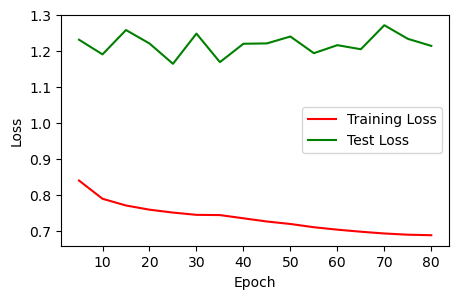

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1203/1203 [00:44<00:00, 27.06it/s]


About to evaluate dnabert-s__epc_pool__phylophlan [seed=12347]
Model dir: /data/bwh-comppath-seq/youn/metaphlan_dset/analyses/pcoa_split/trained_model/phylophlan/dnabert-s/epc_pool/seed_12347
Target tsv output: results/pcoa_split/dnabert-s__epc_pool__phylophlan__12347.tsv
Initializing model with dropout_rate = 0.0
Constructing 2 extra hidden layers.


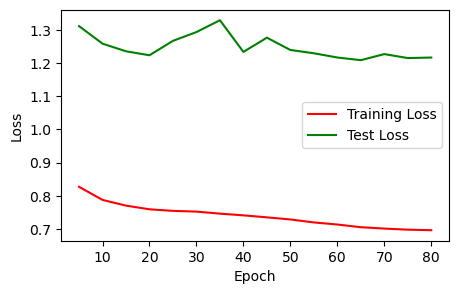

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1203/1203 [00:37<00:00, 31.87it/s]


About to evaluate dnabert-s__epc_pool__phylophlan_metaphlan [seed=12345]
Output for dnabert-s__epc_pool__phylophlan_metaphlan already exists!
About to evaluate evo-1-8k-base_hyena5__epc_pool__phylophlan [seed=12345]
Output for evo-1-8k-base_hyena5__epc_pool__phylophlan already exists!
About to evaluate evo-1-8k-base_hyena5__epc_pool__phylophlan [seed=12346]
Model dir: /data/bwh-comppath-seq/youn/metaphlan_dset/analyses/pcoa_split/trained_model/phylophlan/evo-1-8k-base_hyena5/epc_pool/seed_12346
Target tsv output: results/pcoa_split/evo-1-8k-base_hyena5__epc_pool__phylophlan__12346.tsv
Target torch embedding array: /data/bwh-comppath-seq/youn/metaphlan_dset/embeddings/phylophlan/evo-1-8k-base_hyena5.ipca_d200.pt
Data will be loaded using dtype = torch.float32
Loaded embedding tensor of shape: torch.Size([5351, 384, 200])
Initializing model with dropout_rate = 0.0
Constructing 2 extra hidden layers.


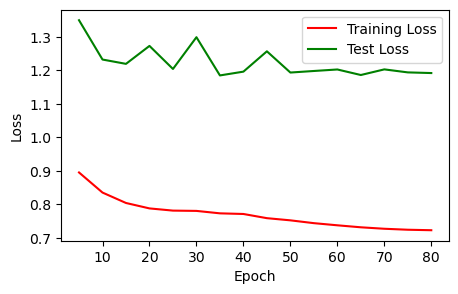

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1203/1203 [00:38<00:00, 30.99it/s]


About to evaluate evo-1-8k-base_hyena5__epc_pool__phylophlan [seed=12347]
Model dir: /data/bwh-comppath-seq/youn/metaphlan_dset/analyses/pcoa_split/trained_model/phylophlan/evo-1-8k-base_hyena5/epc_pool/seed_12347
Target tsv output: results/pcoa_split/evo-1-8k-base_hyena5__epc_pool__phylophlan__12347.tsv
Initializing model with dropout_rate = 0.0
Constructing 2 extra hidden layers.


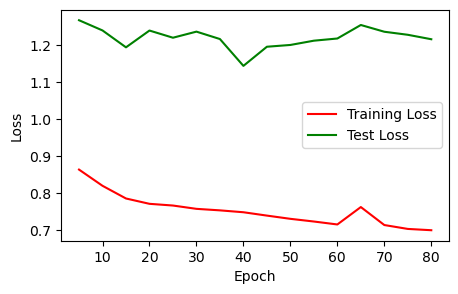

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1203/1203 [00:37<00:00, 32.09it/s]


About to evaluate evo-1-8k-base_hyena5__epc_pool__phylophlan_metaphlan [seed=12345]
Output for evo-1-8k-base_hyena5__epc_pool__phylophlan_metaphlan already exists!
About to evaluate evo2_7b_hyena10__epc_pool__phylophlan [seed=12345]
Output for evo2_7b_hyena10__epc_pool__phylophlan already exists!
About to evaluate evo2_7b_hyena10__epc_pool__phylophlan [seed=12346]
Model dir: /data/bwh-comppath-seq/youn/metaphlan_dset/analyses/pcoa_split/trained_model/phylophlan/evo2_7b_hyena10/epc_pool/seed_12346
Target tsv output: results/pcoa_split/evo2_7b_hyena10__epc_pool__phylophlan__12346.tsv
Target torch embedding array: /data/bwh-comppath-seq/youn/metaphlan_dset/embeddings/phylophlan/evo2_7b_hyena10.ipca_d200.pt
Data will be loaded using dtype = torch.float32
Loaded embedding tensor of shape: torch.Size([5351, 384, 200])
Initializing model with dropout_rate = 0.0
Constructing 2 extra hidden layers.


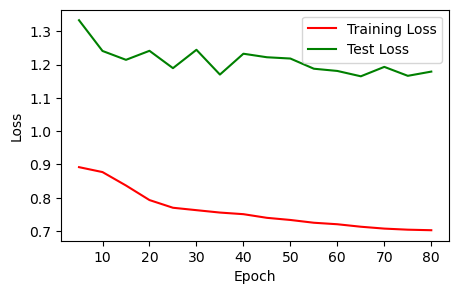

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1203/1203 [00:37<00:00, 32.40it/s]


About to evaluate evo2_7b_hyena10__epc_pool__phylophlan [seed=12347]
Model dir: /data/bwh-comppath-seq/youn/metaphlan_dset/analyses/pcoa_split/trained_model/phylophlan/evo2_7b_hyena10/epc_pool/seed_12347
Target tsv output: results/pcoa_split/evo2_7b_hyena10__epc_pool__phylophlan__12347.tsv
Initializing model with dropout_rate = 0.0
Constructing 2 extra hidden layers.


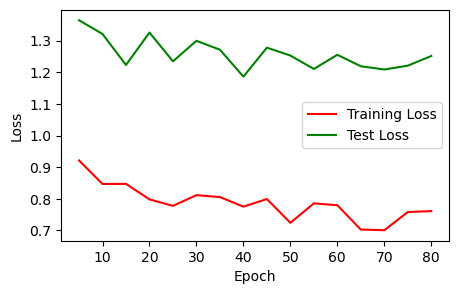

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1203/1203 [00:37<00:00, 32.02it/s]


About to evaluate evo2_7b_hyena10__epc_pool__phylophlan_metaphlan [seed=12345]
Output for evo2_7b_hyena10__epc_pool__phylophlan_metaphlan already exists!
About to evaluate umap_d100_s1000__set_transformer__offline [seed=12345]
Model dir: /data/bwh-comppath-seq/youn/metaphlan_dset/analyses/pcoa_split/trained_model/offline/umap_d100_s1000/set_transformer/seed_12345
Target tsv output: results/pcoa_split/umap_d100_s1000__set_transformer__offline__12345.tsv
Target torch embedding array: /data/bwh-comppath-seq/youn/metaphlan_dset/embeddings/offline/umap_d100_s1000.pt
Data will be loaded using dtype = torch.float32
Loaded embedding tensor of shape: torch.Size([5351, 1, 100])
HierarchicalSetTransformer config: {'dim_hidden': 64, 'num_inds': 16, 'num_heads': 4, 'ln': True, 'marker_embed_dim': 100}


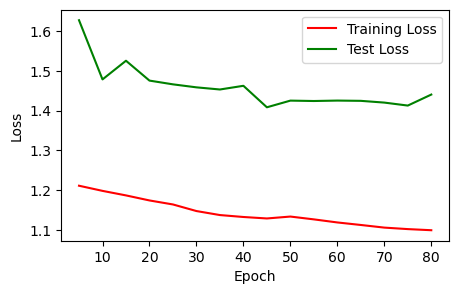

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1203/1203 [00:14<00:00, 82.25it/s]


About to evaluate umap_d100_s1000__set_transformer__offline [seed=12346]
Model dir: /data/bwh-comppath-seq/youn/metaphlan_dset/analyses/pcoa_split/trained_model/offline/umap_d100_s1000/set_transformer/seed_12346
Target tsv output: results/pcoa_split/umap_d100_s1000__set_transformer__offline__12346.tsv
HierarchicalSetTransformer config: {'dim_hidden': 64, 'num_inds': 16, 'num_heads': 4, 'ln': True, 'marker_embed_dim': 100}


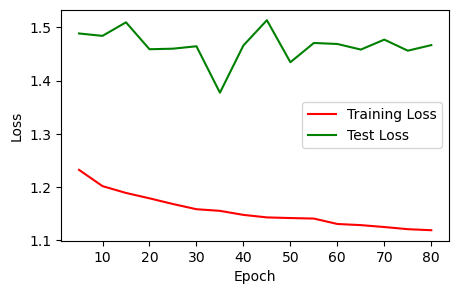

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1203/1203 [00:07<00:00, 154.72it/s]


About to evaluate umap_d100_s1000__set_transformer__offline [seed=12347]
Model dir: /data/bwh-comppath-seq/youn/metaphlan_dset/analyses/pcoa_split/trained_model/offline/umap_d100_s1000/set_transformer/seed_12347
Target tsv output: results/pcoa_split/umap_d100_s1000__set_transformer__offline__12347.tsv
HierarchicalSetTransformer config: {'dim_hidden': 64, 'num_inds': 16, 'num_heads': 4, 'ln': True, 'marker_embed_dim': 100}


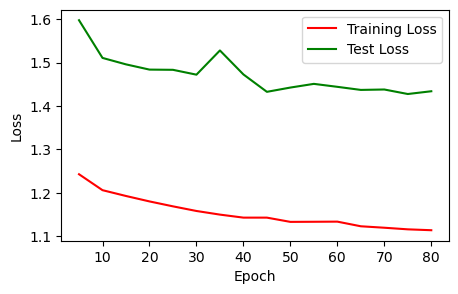

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1203/1203 [00:07<00:00, 151.36it/s]


About to evaluate dnabert-s__set_transformer__phylophlan [seed=12345]
Model dir: /data/bwh-comppath-seq/youn/metaphlan_dset/analyses/pcoa_split/trained_model/phylophlan/dnabert-s/set_transformer/seed_12345
Target tsv output: results/pcoa_split/dnabert-s__set_transformer__phylophlan__12345.tsv
HierarchicalSetTransformer config: {'dim_hidden': 64, 'num_inds': 16, 'num_heads': 4, 'ln': True, 'marker_embed_dim': 200}


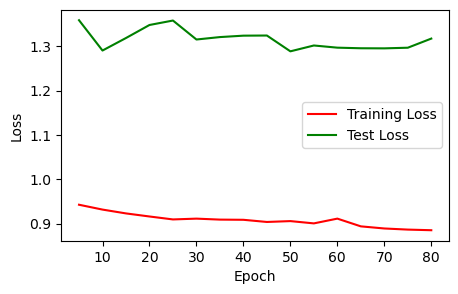

 33%|████████████████████████████████████████████████████████▏                                                                                                                | 400/1203 [00:23<00:46, 17.28it/s]

In [ ]:
evaluate_all("pcoa_split", Path("results") / "pcoa_split", overwrite=False)
# evaluate_ablated("pcoa_split", Path("results") / "pcoa_split", overwrite=True)

In [ ]:
for split_seed in range(1001, 1004):
    analysis_name = f"random_split_{split_seed}"
    print(f"analysis_name: {analysis_name}")
    evaluate_all(analysis_name, Path("results") / analysis_name, overwrite=False)
    # evaluate_ablated(analysis_name, Path("results") / analysis_name, overwrite=False)

# Plotting

## Matplotlib/Seaborn plotting fn

In [36]:
from scipy.stats import wilcoxon

def boxplot_with_paired_significance(data, hue, y, sample_col, show_scatter: bool = False, annot_pvals: bool = False, ax=None, hue_order=None, palette=None, correction='fdr_bh', fontsize: int = 12):
    """
    Draws a seaborn boxplot and annotates pairwise *paired* statistical significance between hue groups, matching by 'Sample' column.
    Uses paired Wilcoxon test with multiple hypothesis correction.
    
    Parameters:
    -----------
    correction : str, default 'holm'
        Method for multiple hypothesis correction. Options: 'bonferroni', 'holm', 'fdr_bh', 'fdr_by'
    """
    import statsmodels.stats.multitest as smt
    
    if hue_order is None:
        hue_order = sorted(data[hue].unique())
    group_locs = {level: i for i, level in enumerate(hue_order)}
    
    # Draw the box plot: only x=hue, y=value
    sb.boxplot(x=hue, y=y, hue=hue, data=data, ax=ax, order=hue_order, hue_order=hue_order, palette=palette, dodge=False, legend=False, showfliers=False)
    if show_scatter:
        sb.stripplot(x=hue, y=y, hue=hue, data=data, ax=ax, order=hue_order, hue_order=hue_order, palette=palette, dodge=False, alpha=0.2, edgecolor='black', linewidth=1.0)

    ax.set_xticks(list(range(len(hue_order))), hue_order, rotation=90, fontsize=fontsize)

    if annot_pvals:
        # Get y-axis range for proper scaling
        ylim = ax.get_ylim()
        y_range = ylim[1] - ylim[0]
        y_max = data[y].max()
        
        # Starting position for annotations (4% above data max)
        y_start = y_max + y_range * 0.04
        
        # Pairwise significance testing
        pairs = list(itertools.combinations(hue_order, 2))
        p_values = []
        test_results = []
        
        # Collect all p-values first
        for h1, h2 in pairs:
            d1 = data[data[hue] == h1][[sample_col, y]]
            d2 = data[data[hue] == h2][[sample_col, y]]
            joined = d1.merge(d2, on=sample_col, suffixes=('_1', '_2'))
            v1 = joined[y + '_1']
            v2 = joined[y + '_2']
            stat, p = wilcoxon(v1, v2, zero_method='wilcox', correction=False)
            p_values.append(p)
            test_results.append((h1, h2, stat, p))
        
        # Apply multiple hypothesis correction
        if len(p_values) > 1:
            rejected, p_corrected, _, _ = smt.multipletests(p_values, method=correction)
        else:
            rejected = [p_values[0] < 0.05] if p_values else []
            p_corrected = p_values
        
        # Annotation with corrected p-values
        annotation_idx = 0  # Counter for positioning annotations
        for idx, (h1, h2, stat, p_raw) in enumerate(test_results):
            p_adj = p_corrected[idx]
            
            stars = '***' if p_adj < 0.001 else '**' if p_adj < 0.01 else '*' if p_adj < 0.05 else 'n.s.'
            
            x1, x2 = group_locs[h1], group_locs[h2]
            
            # Calculate bracket position and height based on y-axis range
            y_bar = y_start + annotation_idx * y_range * 0.15  # 15% spacing between brackets
            bracket_height = y_range * 0.02  # 2% of y-range for bracket height
            text_offset = y_range * 0.001  # offset for text above bracket
            
            # Draw significance bracket
            ax.plot([x1, x1, x2, x2], 
                    [y_bar, y_bar + bracket_height, y_bar + bracket_height, y_bar], 
                    lw=1.2, c='k')
            
            # Add significance text with adjusted p-value info
            text = f"{stars}"
            ax.text((x1 + x2) / 2, y_bar + bracket_height + text_offset, 
                    text, ha='center', va='bottom', color='k', fontsize=11)
            
            annotation_idx += 1
        
        # Add correction method info to plot
        ax.text(0.02, 0.98, f'Multiple comparisons: {correction}', 
                transform=ax.transAxes, verticalalignment='top', fontsize=10, 
                bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgray', alpha=0.7))
    else:
        print("Skipping p-value annotation.")
    
    return ax

## draw plots

In [73]:
# def plot_result(results_dir: Path, model_configs, baseline_names, torch_model_colors):
#     eval_results_dfs = []
#     method_order = []
#     palette = dict()

#     baseline_colors = iter(sb.color_palette('Greys', n_colors=16))
#     for baseline_name in baseline_names:
#         tsv_output_path = results_dir / f'{baseline_name}.tsv'
#         if tsv_output_path.exists():
#             eval_results_dfs.append(pd.read_csv(tsv_output_path, sep='\t').assign(Method=baseline_name))
#             method_order.append(baseline_name)
#             palette[baseline_name] = next(baseline_colors)

#     for embedding_feature_name, embedding_model_name, inference_model_name in model_configs:
#         tsv_output_path = results_dir / f"{embedding_model_name}__{inference_model_name}__{embedding_feature_name}.tsv"
#         if tsv_output_path.exists():
#             method_name = f"{embedding_model_name}__{inference_model_name}__{embedding_feature_name}"
#             eval_results_dfs.append(pd.read_csv(tsv_output_path, sep='\t').assign(Method=method_name))
#             method_order.append(method_name)
#             palette[method_name] = torch_model_colors[embedding_model_name]

#     eval_result_df = pd.concat(eval_results_dfs, ignore_index=True)

#     fig, axes = plt.subplots(1, 4, figsize=(18, 10))
#     axes = axes.flatten()
#     boxplot_with_paired_significance(eval_result_df.loc[eval_result_df['Method'].isin(method_order)], hue='Method', y='KL_err', sample_col='Sample', ax=axes[0], palette=palette, hue_order=method_order, annot_pvals=False)
#     boxplot_with_paired_significance(eval_result_df.loc[eval_result_df['Method'].isin(method_order)], hue='Method', y='RMSL_err', sample_col='Sample', ax=axes[1], palette=palette, hue_order=method_order, annot_pvals=False)
#     boxplot_with_paired_significance(eval_result_df.loc[eval_result_df['Method'].isin(method_order)], hue='Method', y='BrayCurtis', sample_col='Sample', ax=axes[2], palette=palette, hue_order=method_order, annot_pvals=False)
#     boxplot_with_paired_significance(eval_result_df.loc[eval_result_df['Method'].isin(method_order)], hue='Method', y='RootJensenShannon', sample_col='Sample', ax=axes[3], palette=palette, hue_order=method_order, annot_pvals=False)
#     return eval_result_df


In [74]:
# model_configs = [
#     ("offline", "umap_d100_s1000", "epc_pool"),
#     ("phylophlan", "dnabert-s", "epc_pool"),
#     # ("phylophlan_metaphlan", "dnabert-s", "epc_pool"),
#     ("phylophlan", "evo-1-8k-base_hyena5", "epc_pool"),
#     # ("phylophlan_metaphlan", "evo-1-8k-base_hyena5", "epc_pool"),
#     ("phylophlan", "evo2_7b_hyena10", "epc_pool"),
#     # ("phylophlan_metaphlan", "evo2_7b_hyena10", "epc_pool"),
# ]
# baseline_names = [
#     'uniform', 'sgb_nearest_neighbor',
#     'sgb_nearest_neighbor_KNN_10',
#     'sgb_nearest_neighbor_KNN_20',
#     'sgb_nearest_neighbor_KNN_30',
#     'sgb_nearest_neighbor_KNN_40',
# ]
# torch_model_colors = {
#     'umap_d100_s1000': 'violet',
#     'pcoa_d100_s1000': 'violet',
#     'dnabert-s': '#e88870ff',
#     'evo-1-8k-base_hyena5': '#8db8d0ff',
#     'evo2_7b_hyena10': '#91c590ff',
# }

# plot_result(Path("results") / "pcoa_split", model_configs, baseline_names, torch_model_colors)

# Figures for paper

In [37]:
import matplotlib.patches as mpatches
from collections import defaultdict

def render_legend_groups(method_names: List[str], color_dict: Dict[str, np.ndarray], display_names_dict: Dict[str, str], ax, font_size: int):
    def get_group_of(_method): 
        if _method.startswith("sgb_nearest_neighbor") or _method == "uniform":
            return "baseline"
        else:
            return _method.split(":")[0]
            
    # Group handles by prefix before ':'
    groups = defaultdict(list)
    for method_name in method_names:
        group = get_group_of(method_name)
        color = color_dict[method_name]
        groups[group].append(mpatches.Patch(color=color, label=display_names_dict[method_name]))

    columns = list(groups.values())
    n_cols = len(columns)
    n_rows = max(len(col) for col in columns)

    # Pad each column to n_rows with unique blank patches
    group_names = list(groups.keys())
    padded_columns = []
    for group, col in groups.items():
        padded_columns.append(
            col + [mpatches.Patch(visible=False, label="") for _ in range(n_rows - len(col))]
        )
    print("Rendering n_rows = {}, n_cols = {} Legend layout.".format(n_rows, n_cols))

    # Interleave row by row so matplotlib's row-by-row fill puts items in the right column
    interleaved = []
    for col in padded_columns:
        interleaved.extend(col)
        
    ax.legend(
        handles=interleaved,
        ncols=n_cols,
        loc="center",
        frameon=False,
        columnspacing=1.0,
        prop={'family': "Fira Sans", 'weight': 'normal', 'size': font_size}
    )

In [38]:
# ===================== pick models to draw
# from typing import NamedTuple
# import itertools


# class TorchInferenceCategory(NamedTuple):
#     model_name: str
#     gene_set_name: str
#     model_name_display: str  # for plotting
#     model_name_latex: str  # for rending as LaTeX table


# class PredCategory(NamedTuple):
#     model_name: str
#     model_name_display: str
#     model_name_latex: str


# class BaselineCategory(NamedTuple):
#     method_name: str
#     method_name_display: str
#     method_name_latex: str



# # ==================== dataframes
# def extract_concat_result(results_dir: Path, baseline_methods: List, embed_models: List, pred_models: List):
#     eval_result_dfs = []
#     plot_palette = {}
#     method_order = []
    
#     # baseline methods
#     for baseline in baseline_methods:
#         tsv_path = results_dir / f"{baseline.method_name}.tsv"
#         if not tsv_path.exists():
#             print("Baseline result tsv does not exist: {}".format(tsv_path))
#             continue
#         method_name = baseline.method_name
#         method_order.append(method_name)
#         eval_result_dfs.append(
#             pd.read_csv(tsv_path, sep='\t').assign(
#                 Method=method_name
#             )
#         )
    
#     # torch models
#     for embed_cat in embed_models:
#         for pred_idx, pred_cat in enumerate(pred_models):
#             tsv_path = results_dir / f"{embed_cat.model_name}__{pred_cat.model_name}__{embed_cat.gene_set_name}.tsv"
#             if not tsv_path.exists():
#                 print("Torch result tsv does not exist: {}".format(tsv_path))
#                 continue
            
#             method_name = f'{embed_cat.model_name}:{pred_cat.model_name}'
#             method_order.append(method_name)
#             eval_result_dfs.append(
#                 pd.read_csv(tsv_path, sep='\t').assign(
#                     Method=method_name,
#                     GeneSet=embed_cat.gene_set_name
#                 )
#             )
    
    
#     eval_result_df = pd.concat(eval_result_dfs, ignore_index=True)
#     return eval_result_df

In [39]:
# embed_models_to_plot = [
#     TorchInferenceCategory('dnabert-s', 'phylophlan', 'DNABERT-S', 'DNABERT-S'), 
#     TorchInferenceCategory('evo-1-8k-base_hyena5', 'phylophlan', 'Evo 1', 'Evo 1'), 
#     TorchInferenceCategory('evo2_7b_hyena10', 'phylophlan', 'Evo 2', 'Evo 2')
# ]
# embed_models_to_plot += [
#     TorchInferenceCategory('umap_d100_s1000', 'offline', 'UMAP (d=100)', 'UMAP ($d=100$)'),
# ]

# pred_models_to_plot = [
#     PredCategory('epc_pool', 'MLP Depth 3', 'MLP Depth 3'),
#     PredCategory('set_transformer', 'Set-Transformer', 'Set-Transformer'),
# ]

# baseline_methods_to_plot = [
#     BaselineCategory('uniform', 'Uniform', 'Uniform'),
#     BaselineCategory('sgb_nearest_neighbor', 'NN-Global', 'NN-Global'),
#     BaselineCategory('sgb_nearest_neighbor_KNN_10', 'kNN (k=10)', 'kNN ($k=10$)'),
#     BaselineCategory('sgb_nearest_neighbor_KNN_20', 'kNN (k=20)', 'kNN ($k=20$)'),
#     BaselineCategory('sgb_nearest_neighbor_KNN_30', 'kNN (k=30)', 'kNN ($k=30$)'),
#     BaselineCategory('sgb_nearest_neighbor_KNN_40', 'kNN (k=40)', 'kNN ($k=40$)'),
# ]


# name_mapping = {
#     f'{embed_cat.model_name}:{pred_cat.model_name}': f'{embed_cat.model_name_display} ({pred_cat.model_name_display})'
#     for embed_cat, pred_cat in itertools.product(embed_models_to_plot, pred_models_to_plot)
# } | {
#     baseline_cat.method_name: baseline_cat.method_name_display
#     for baseline_cat in baseline_methods_to_plot
# }


# color_iters = {
#     'dnabert-s': iter(sb.color_palette('Reds', n_colors=4)), 
#     'evo-1-8k-base_hyena5': iter(sb.color_palette('Blues', n_colors=4)),
#     'evo2_7b_hyena10': iter(sb.color_palette('Greens', n_colors=4)),
# } | {
#     'umap_d100_s1000': iter(sb.color_palette('Purples', n_colors=4)),
# }
# baseline_colors = iter(sb.color_palette('Grays', 8))
# plot_palette = {
#     f'{embed_cat.model_name}:{pred_cat.model_name}': next(color_iters[embed_cat.model_name])
#     for embed_cat, pred_cat in itertools.product(embed_models_to_plot, pred_models_to_plot)
# } | {
#     baseline_cat.method_name: next(baseline_colors)
#     for baseline_cat in baseline_methods_to_plot
# }


# pcoa_result_df = extract_concat_result(Path('results') / 'pcoa_split', baseline_methods_to_plot, embed_models_to_plot, pred_models_to_plot)
# rng_result_dfs = {
#     rng_seed: extract_concat_result(Path('results') / f'random_split_{rng_seed}', baseline_methods_to_plot, embed_models_to_plot, pred_models_to_plot)
#     for rng_seed in [1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009, 1010]
# }

In [64]:
def extract_concat_result(results_dir: Path, method_names: List[str]):
    eval_result_dfs = []

    # search for all seeded runs
    def is_baseline(name) -> bool:
        if 'uniform' in name or 'nearest_neighbor' in name:
            return True
        else:
            return False

    for method_name in method_names:
        # parse gene set name, if applicable.
        tokens = method_name.split("__")
        if len(tokens) == 3:
            # found torch model.
            prediction_method_name = "__".join(tokens[:2])
            gene_set_name = tokens[2]
        else:
            # found baseline.
            prediction_method_name = method_name
            gene_set_name = 'offline'
        
        if is_baseline(method_name):
            tsv_path = results_dir / f'{method_name}.tsv'
            seed_val = np.nan
            print(tsv_path)
            eval_result_dfs.append(
                pd.read_csv(tsv_path, sep='\t').assign(
                    Method=method_name,
                    GeneSet=gene_set_name,
                    PredictionMethod=prediction_method_name,
                    Seed=seed_val,
                )
            )
        else:
            for tsv_path in results_dir.glob(f"{method_name}__*.tsv"):
                seed_val = int(tsv_path.stem.split("__")[-1])
                eval_result_dfs.append(
                    pd.read_csv(tsv_path, sep='\t').assign(
                        Method=method_name,
                        GeneSet=gene_set_name,
                        PredictionMethod=prediction_method_name,
                        Seed=seed_val,
                    )
                )
    
    eval_result_df = pd.concat(eval_result_dfs, ignore_index=True)
    return eval_result_df

results/pcoa_split/uniform.tsv
results/pcoa_split/sgb_nearest_neighbor.tsv
results/pcoa_split/sgb_nearest_neighbor_KNN_10.tsv
results/pcoa_split/sgb_nearest_neighbor_KNN_20.tsv
results/pcoa_split/sgb_nearest_neighbor_KNN_30.tsv
results/pcoa_split/sgb_nearest_neighbor_KNN_40.tsv
results/random_split_1001/uniform.tsv
results/random_split_1001/sgb_nearest_neighbor.tsv
results/random_split_1001/sgb_nearest_neighbor_KNN_10.tsv
results/random_split_1001/sgb_nearest_neighbor_KNN_20.tsv
results/random_split_1001/sgb_nearest_neighbor_KNN_30.tsv
results/random_split_1001/sgb_nearest_neighbor_KNN_40.tsv
['uniform', 'sgb_nearest_neighbor', 'sgb_nearest_neighbor_KNN_10', 'sgb_nearest_neighbor_KNN_20', 'sgb_nearest_neighbor_KNN_30', 'sgb_nearest_neighbor_KNN_40', 'dnabert-s__epc_pool__phylophlan', 'evo-1-8k-base_hyena5__epc_pool__phylophlan', 'evo2_7b_hyena10__epc_pool__phylophlan', 'umap_d100_s1000__epc_pool__offline', 'dnabert-s__set_transformer__phylophlan', 'evo-1-8k-base_hyena5__set_transformer

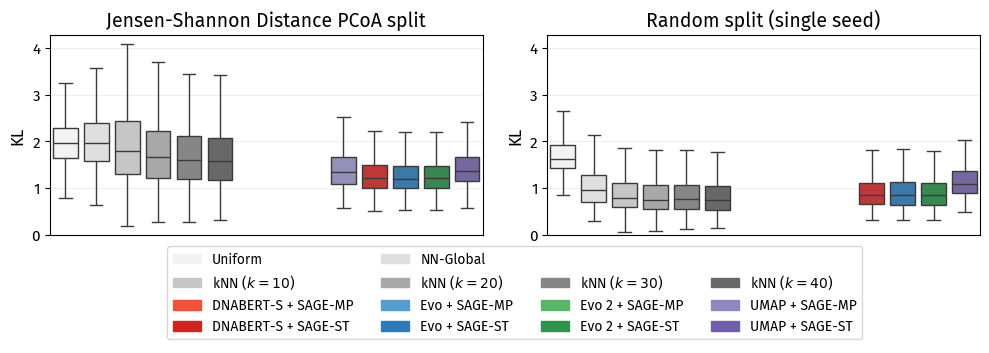

In [62]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from itertools import zip_longest

# ==================== data
baseline_methods_to_plot = [
    'uniform',
    'sgb_nearest_neighbor',
    'sgb_nearest_neighbor_KNN_10',
    'sgb_nearest_neighbor_KNN_20',
    'sgb_nearest_neighbor_KNN_30',
    'sgb_nearest_neighbor_KNN_40',
]
torch_models_to_plot = [
    'dnabert-s__epc_pool__phylophlan',
    'evo-1-8k-base_hyena5__epc_pool__phylophlan',
    'evo2_7b_hyena10__epc_pool__phylophlan',
    'umap_d100_s1000__epc_pool__offline',
    'dnabert-s__set_transformer__phylophlan',
    'evo-1-8k-base_hyena5__set_transformer__phylophlan',
    'evo2_7b_hyena10__set_transformer__phylophlan',
    'umap_d100_s1000__set_transformer__offline',
]
pcoa_result_df = extract_concat_result(Path('results') / 'pcoa_split', baseline_methods_to_plot + torch_models_to_plot)
rng_result_dfs = {
    rng_seed: extract_concat_result(Path('results') / f'random_split_{rng_seed}', baseline_methods_to_plot + torch_models_to_plot)
    # for rng_seed in [1001, 1002, 1003, 1004]
    for rng_seed in [1001]
}


# ==================== plot
width = 12
height = 4
FONT_SIZE = 12
TITLE_FONT_SIZE = 14
LEGEND_FONT_SIZE = 10
xtick_angle = 50

fig = plt.figure(figsize=(width, height))
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.05, wspace=0.15, width_ratios=[1, 1], height_ratios=[1, 0.5])


this_method_order = baseline_methods_to_plot + torch_models_to_plot
print(this_method_order)
baseline_colors = iter(sb.color_palette('Grays', 8))

plot_palette = {
    'uniform': next(baseline_colors),
    'sgb_nearest_neighbor': next(baseline_colors),
    'sgb_nearest_neighbor_KNN_10': next(baseline_colors),
    'sgb_nearest_neighbor_KNN_20': next(baseline_colors),
    'sgb_nearest_neighbor_KNN_30': next(baseline_colors),
    'sgb_nearest_neighbor_KNN_40': next(baseline_colors),
    'dnabert-s__epc_pool__phylophlan': sb.color_palette('Reds', n_colors=6)[3],
    'evo-1-8k-base_hyena5__epc_pool__phylophlan': sb.color_palette('Blues', n_colors=6)[3],
    'evo2_7b_hyena10__epc_pool__phylophlan': sb.color_palette('Greens', n_colors=6)[3],
    'umap_d100_s1000__epc_pool__offline': sb.color_palette('Purples', n_colors=6)[3],
    'dnabert-s__set_transformer__phylophlan': sb.color_palette('Reds', n_colors=6)[4],
    'evo-1-8k-base_hyena5__set_transformer__phylophlan': sb.color_palette('Blues', n_colors=6)[4],
    'evo2_7b_hyena10__set_transformer__phylophlan': sb.color_palette('Greens', n_colors=6)[4],
    'umap_d100_s1000__set_transformer__offline': sb.color_palette('Purples', n_colors=6)[4],
}
name_mapping = {
    'uniform': 'Uniform',
    'sgb_nearest_neighbor': 'NN-Global',
    'sgb_nearest_neighbor_KNN_10': r'kNN ($k=10$)',
    'sgb_nearest_neighbor_KNN_20': r'kNN ($k=20$)',
    'sgb_nearest_neighbor_KNN_30': r'kNN ($k=30$)',
    'sgb_nearest_neighbor_KNN_40': r'kNN ($k=40$)',
    
    'dnabert-s__epc_pool__phylophlan': 'DNABERT-S + SAGE-MP',
    'evo-1-8k-base_hyena5__epc_pool__phylophlan': 'Evo + SAGE-MP',
    'evo2_7b_hyena10__epc_pool__phylophlan': 'Evo 2 + SAGE-MP',
    'umap_d100_s1000__epc_pool__offline': 'UMAP + SAGE-MP',
    
    'dnabert-s__set_transformer__phylophlan': 'DNABERT-S + SAGE-ST',
    'evo-1-8k-base_hyena5__set_transformer__phylophlan': 'Evo + SAGE-ST',
    'evo2_7b_hyena10__set_transformer__phylophlan': 'Evo 2 + SAGE-ST',
    'umap_d100_s1000__set_transformer__offline': 'UMAP + SAGE-ST',
}

legend_ax = fig.add_subplot(gs[-1, :])
legend_ax.axis("off")
cat1 = ['uniform', 'sgb_nearest_neighbor']
cat2 = ['sgb_nearest_neighbor_KNN_10', 'sgb_nearest_neighbor_KNN_20', 'sgb_nearest_neighbor_KNN_30', 'sgb_nearest_neighbor_KNN_40']
cat3 = ['dnabert-s__epc_pool__phylophlan', 'evo-1-8k-base_hyena5__epc_pool__phylophlan', 'evo2_7b_hyena10__epc_pool__phylophlan', 'umap_d100_s1000__epc_pool__offline']
cat4 = ['dnabert-s__set_transformer__phylophlan', 'evo-1-8k-base_hyena5__set_transformer__phylophlan', 'evo2_7b_hyena10__set_transformer__phylophlan', 'umap_d100_s1000__set_transformer__offline']
columns = [cat1, cat2, cat3, cat4]
blank = mpatches.Patch(alpha=0, label=" ")

handles = [
    mpatches.Patch(color=plot_palette[m], label=name_mapping[m]) if m else blank
    for row in zip_longest(*columns) for m in row
]

legend_ax.legend(handles=handles, loc="center", frameon=True, title="Methods", ncol=4)

ax1 = fig.add_subplot(gs[0, 0])  # Spans rows 0-1, column 0
# ax2 = fig.add_subplot(gs[1, 0])  # Spans rows 0-1, column 1
boxplot_with_paired_significance(pcoa_result_df.loc[(pcoa_result_df['Method'].isin(this_method_order) & (pcoa_result_df['Seed'] == 12346)) | pcoa_result_df['Method'].isin(baseline_methods_to_plot)], hue='Method', y='KL_err', sample_col='Sample', ax=ax1, palette=plot_palette, hue_order=this_method_order, annot_pvals=False, fontsize=FONT_SIZE)
ax1.set_ylabel("KL", fontsize=FONT_SIZE, fontname="Fira Sans", fontweight='normal')
ax1.set_xlabel(None)
# ax1.set_xticks(range(len(this_method_order)), [name_mapping[_m] for _m in this_method_order], rotation=xtick_angle, ha='right', rotation_mode='anchor', fontname="Fira Sans", fontweight='normal')
ax1.set_title("Jensen-Shannon Distance PCoA split", fontname="Fira Sans", fontweight='normal', fontsize=TITLE_FONT_SIZE)
ax1.set_xticks([])

# boxplot_with_paired_significance(pcoa_result_df.loc[pcoa_result_df['Method'].isin(this_method_order)], hue='Method', y='RMSL_err', sample_col='Sample', ax=ax2, palette=plot_palette, hue_order=this_method_order, annot_pvals=False, fontsize=FONT_SIZE)
# ax2.set_ylabel("RMS-log", fontsize=FONT_SIZE, fontname="Fira Sans", fontweight='normal')
# ax2.set_xlabel(None)
# # ax2.set_xticks(range(len(this_method_order)), [name_mapping[_m] for _m in this_method_order], rotation=xtick_angle, ha='right', rotation_mode='anchor', fontname="Fira Sans", fontweight='normal')
# ax2.set_xticks([])


ax3 = fig.add_subplot(gs[0, 1])  # Spans rows 0-1, column 0
# ax4 = fig.add_subplot(gs[1, 1])  # Spans rows 0-1, column 1
_result_df = rng_result_dfs[1001]
boxplot_with_paired_significance(_result_df.loc[(_result_df['Method'].isin(this_method_order) & (_result_df['Seed'] == 12346)) | _result_df['Method'].isin(baseline_methods_to_plot)], hue='Method', y='KL_err', sample_col='Sample', ax=ax3, palette=plot_palette, hue_order=this_method_order, annot_pvals=False, fontsize=FONT_SIZE)
ax3.set_ylabel("KL", fontsize=FONT_SIZE, fontname="Fira Sans", fontweight='normal')
ax3.set_xlabel(None)
# ax3.set_xticks(range(len(this_method_order)), [name_mapping[_m] for _m in this_method_order], rotation=xtick_angle, ha='right', rotation_mode='anchor', fontname="Fira Sans", fontweight='normal')
ax3.set_title("Random split (single seed)", fontname="Fira Sans", fontweight='normal', fontsize=TITLE_FONT_SIZE)
ax3.set_xticks([])

# boxplot_with_paired_significance(_result_df.loc[_result_df['Method'].isin(this_method_order)], hue='Method', y='RMSL_err', sample_col='Sample', ax=ax4, palette=plot_palette, hue_order=this_method_order, annot_pvals=False, fontsize=FONT_SIZE)
# ax4.set_ylabel("RMS-log", fontsize=FONT_SIZE, fontname="Fira Sans", fontweight='normal')
# ax4.set_xlabel(None)
# # ax4.set_xticks(range(len(this_method_order)), [name_mapping[_m] for _m in this_method_order], rotation=xtick_angle, ha='right', rotation_mode='anchor', fontname="Fira Sans", fontweight='normal')
# ax4.set_xticks([])

ax3.sharey(ax1)
# ax4.sharey(ax2)



from matplotlib.font_manager import FontProperties
custom_font = FontProperties(family='Fira Sans', weight='normal', size=11)
for ax in [ax1, ax3]:
    for label in ax.get_xticklabels():
        label.set_fontproperties(custom_font)
    for label in ax.get_yticklabels():
        label.set_fontproperties(custom_font)
    ax.grid(axis="y", linestyle="-", alpha=0.2)


legend_ax.get_legend().set_title("", prop=custom_font)
for text in legend_ax.get_legend().get_texts():
    text.set_fontsize(LEGEND_FONT_SIZE)
    text.set_fontfamily("Fira Sans")
    text.set_fontweight("normal")


plt.savefig("results/sgb_pcoa_and_rng_1001_metrics.pdf", bbox_inches='tight', transparent=True)
plt.savefig("results/sgb_pcoa_and_rng_1001_metrics.png", dpi=800, bbox_inches='tight', transparent=True)
print("done")

In [59]:
# ==================== render table
this_method_order = baseline_methods_to_plot + torch_models_to_plot
latex_mapping = {
    'uniform': 'Uniform',
    'sgb_nearest_neighbor': 'NN-Global',
    'sgb_nearest_neighbor_KNN_10': r'kNN ($k=10$)',
    'sgb_nearest_neighbor_KNN_20': r'kNN ($k=20$)',
    'sgb_nearest_neighbor_KNN_30': r'kNN ($k=30$)',
    'sgb_nearest_neighbor_KNN_40': r'kNN ($k=40$)',
    
    'dnabert-s__epc_pool__phylophlan': 'DNABERT-S + SAGE-MP',
    'evo-1-8k-base_hyena5__epc_pool__phylophlan': 'Evo + SAGE-MP',
    'evo2_7b_hyena10__epc_pool__phylophlan': 'Evo 2 + SAGE-MP',
    'umap_d100_s1000__epc_pool__offline': 'UMAP + SAGE-MP',
    
    'dnabert-s__set_transformer__phylophlan': 'DNABERT-S + SAGE-ST',
    'evo-1-8k-base_hyena5__set_transformer__phylophlan': 'Evo + SAGE-ST',
    'evo2_7b_hyena10__set_transformer__phylophlan': 'Evo 2 + SAGE-ST',
    'umap_d100_s1000__set_transformer__offline': 'UMAP + SAGE-ST',
}


_sections = []
for rng_seed, rng_result_df in rng_result_dfs.items():
    print("RNG SEED:", rng_seed)
    agg = rng_result_df[['Method', 'KL_err']].groupby('Method').median().assign(Seed=rng_seed).reset_index()
    _sections.append(agg)
rng_agg_df = pd.concat(_sections, ignore_index=False)
del _sections


# raise Exception("HERE")

_x = rng_agg_df.loc[rng_agg_df['Method'].isin(this_method_order)]
_x = _x.assign(Method=_x['Method'].map(latex_mapping))[['Method', 'KL_err']].groupby("Method").median()
_y = pcoa_result_df.loc[pcoa_result_df['Method'].isin(this_method_order)].reset_index(drop=True)
_y = _y.assign(Method=_y['Method'].map(latex_mapping))[['Method', 'KL_err']].groupby("Method").median()

# Build the ordered list of display names from this_method_order
ordered_display = [latex_mapping[m] for m in this_method_order if m in latex_mapping]

# Then reindex after the merge
display_df = _x.merge(
    _y,
    left_index=True, right_index=True,
    how="outer",
    suffixes=['_rng', '_pcoa']
).reindex(ordered_display)

def fmt_cell(val, is_min):
    if is_min:
        return rf'\textbf{{{val:.4f}}}'
    return f'{val:.4f}'

min_pcoa = display_df['KL_err_pcoa'].min()
min_rng = display_df['KL_err_rng'].min()

display_df['JS-Maximizing Split (KL)'] = display_df.apply(
    lambda r: fmt_cell(r['KL_err_pcoa'], r['KL_err_pcoa'] == min_pcoa), axis=1
)
display_df['Random Split (KL)'] = display_df.apply(
    lambda r: fmt_cell(r['KL_err_rng'], r['KL_err_rng'] == min_rng), axis=1
)

display(display_df)

# Generate LaTeX with booktabs
latex = display_df[['JS-Maximizing Split (KL)', 'Random Split (KL)']].to_latex(
    index=True,
    escape=False,
    column_format="lcc",
    caption="Test set KL divergence evaluation of methods. \\textbf{JS-Maximizing Split}: median test KL for the $D_{JS}$ maximizing split. \\textbf{Random Split}: median-of-median test KL across ten random seeds. The minimal value in each column is highlighted in bold.",
    label="table:benchmark_sgb",
    position="ht",
)

# Manually swap hlines for booktabs rules
lines = latex.splitlines()
result = []
for i, line in enumerate(lines):
    result.append(line)
    if line.strip().endswith(r"\\") and not any(
        marker in line for marker in [r"\toprule", r"\midrule", r"\bottomrule"]
    ):
        result.append(r"\midrule")
latex = "\n".join(result)
print(latex)

RNG SEED: 1001
RNG SEED: 1002
RNG SEED: 1003
RNG SEED: 1004
RNG SEED: 1005
RNG SEED: 1006
RNG SEED: 1007
RNG SEED: 1008
RNG SEED: 1009
RNG SEED: 1010


,KL_err_rng,KL_err_pcoa,JS-Maximizing Split (KL),Random Split (KL)
Method,,,,
Uniform,1.619637,1.956493,1.9565,1.6196
NN-Global,0.953509,1.961392,1.9614,0.9535
kNN ($k=10$),0.815485,1.800566,1.8006,0.8155
kNN ($k=20$),0.774577,1.657699,1.6577,0.7746
kNN ($k=30$),0.762337,1.598742,1.5987,0.7623
kNN ($k=40$),0.756772,1.591657,1.5917,0.7568
DNABERT-S + SAGE-MP,0.699011,1.199342,1.1993,0.6990
Evo + SAGE-MP,0.712532,1.153264,1.1533,0.7125
Evo 2 + SAGE-MP,0.698510,1.127211,\textbf{1.1272},\textbf{0.6985}


\begin{table}[ht]
\caption{Test set KL divergence evaluation of methods. \textbf{JS-Maximizing Split}: median test KL for the $D_{JS}$ maximizing split. \textbf{Random Split}: median-of-median test KL across ten random seeds. The minimal value in each column is highlighted in bold.}
\label{table:benchmark_sgb}
\begin{tabular}{lcc}
\toprule
 & JS-Maximizing Split (KL) & Random Split (KL) \\
\midrule
Method &  &  \\
\midrule
\midrule
Uniform & 1.9565 & 1.6196 \\
\midrule
NN-Global & 1.9614 & 0.9535 \\
\midrule
kNN ($k=10$) & 1.8006 & 0.8155 \\
\midrule
kNN ($k=20$) & 1.6577 & 0.7746 \\
\midrule
kNN ($k=30$) & 1.5987 & 0.7623 \\
\midrule
kNN ($k=40$) & 1.5917 & 0.7568 \\
\midrule
DNABERT-S + SAGE-MP & 1.1993 & 0.6990 \\
\midrule
Evo + SAGE-MP & 1.1533 & 0.7125 \\
\midrule
Evo 2 + SAGE-MP & \textbf{1.1272} & \textbf{0.6985} \\
\midrule
UMAP + SAGE-MP & 1.3207 & 0.9378 \\
\midrule
DNABERT-S + SAGE-ST & 1.2025 & 0.8582 \\
\midrule
Evo + SAGE-ST & 1.2241 & 0.8617 \\
\midrule
Evo 2 + SAGE-ST &

In [60]:
from scipy import stats
from statsmodels.stats.multitest import multipletests
import numpy as np

# ==================== Statistical Testing

def get_paired_kl(result_df, method_a, method_b):
    """Extract paired KL values aligned by SampleId for two methods."""
    df_a = result_df.loc[result_df['Method'] == method_a, ['SampleId', 'KL_err']]
    df_b = result_df.loc[result_df['Method'] == method_b, ['SampleId', 'KL_err']]
    merged = df_a.merge(df_b, on='SampleId', suffixes=('_a', '_b'))
    return merged['KL_err_a'].values, merged['KL_err_b'].values

def run_pairwise_wilcoxon(result_df, method_order, latex_mapping):
    display_names = [latex_mapping[m] for m in method_order if m in latex_mapping]
    n = len(display_names)
    pairs = [(i, j) for i in range(n) for j in range(i+1, n)]

    pvals_raw = []
    for i, j in pairs:
        m_a = method_order[i]
        m_b = method_order[j]
        a, b = get_paired_kl(result_df, m_a, m_b)
        _, p = stats.wilcoxon(a, b, alternative='two-sided')
        pvals_raw.append(p)

    _, pvals_corrected, _, _ = multipletests(pvals_raw, method='fdr_bh')

    pval_df = pd.DataFrame(np.nan, index=display_names, columns=display_names)
    for (i, j), p in zip(pairs, pvals_corrected):
        pval_df.iloc[i, j] = p
        pval_df.iloc[j, i] = p

    return pval_df

# JS-maximizing split: full sample-level KL
pval_matrix_pcoa = run_pairwise_wilcoxon(pcoa_result_df, this_method_order, latex_mapping)

# Random split: use first seed only
first_seed = list(rng_result_dfs.keys())[0]
pval_matrix_rng = run_pairwise_wilcoxon(rng_result_dfs[first_seed], this_method_order, latex_mapping)

# ==================== Render as LaTeX 2D grids

def pval_to_latex_cell(p, threshold=0.05):
    if np.isnan(p):
        return r'--'
    elif p < threshold:
        return rf'\textbf{{{p:.3f}}}$^*$'
    else:
        return rf'{{\color{{gray}}{p:.3f}}}'

def render_pval_table(pval_df, caption, label):
    methods = pval_df.index.tolist()
    n = len(methods)

    col_format = 'l' + 'c' * n
    header = ' & '.join([''] + methods) + r' \\'

    rows = []
    for i in range(n):
        cells = [methods[i]]
        for j in range(n):
            if i == j:
                cells.append(r'--')
            else:
                cells.append(pval_to_latex_cell(pval_df.iloc[i, j]))
        rows.append(' & '.join(cells) + r' \\')

    grid_table = '\n'.join([
        rf'\begin{{table}}[ht]',
        r'\centering',
        r'\resizebox{\textwidth}{!}{',
        rf'\begin{{tabular}}{{{col_format}}}',
        r'\toprule',
        header,
        r'\midrule',
        '\n'.join(rows),
        r'\bottomrule',
        r'\end{tabular}',
        r'}',
        r'\vspace{4pt}',
        rf'\caption{{{caption}}}',
        rf'\label{{{label}}}',
        r'\end{table}',
    ])

    return grid_table

grid_rng = render_pval_table(
    pval_matrix_rng,
    caption=r'Pairwise Wilcoxon signed-rank p-values (BH-corrected) on per-sample KL, random split (single seed). Bold$^*$: $p < 0.05$.',
    label='table:pval_rng'
)

grid_pcoa = render_pval_table(
    pval_matrix_pcoa,
    caption=r'Pairwise Wilcoxon signed-rank p-values (BH-corrected) on per-sample KL, JS-maximizing split. Bold$^*$: $p < 0.05$.',
    label='table:pval_pcoa'
)

print("% ===== Random Split p-value grid =====")
print(grid_rng)
print()
print("% ===== JS-Maximizing Split p-value grid =====")
print(grid_pcoa)

% ===== Random Split p-value grid =====
\begin{table}[ht]
\centering
\resizebox{\textwidth}{!}{
\begin{tabular}{lcccccccccccccc}
\toprule
 & Uniform & NN-Global & kNN ($k=10$) & kNN ($k=20$) & kNN ($k=30$) & kNN ($k=40$) & DNABERT-S + SAGE-MP & Evo + SAGE-MP & Evo 2 + SAGE-MP & UMAP + SAGE-MP & DNABERT-S + SAGE-ST & Evo + SAGE-ST & Evo 2 + SAGE-ST & UMAP + SAGE-ST \\
\midrule
Uniform & -- & \textbf{0.000}$^*$ & \textbf{0.000}$^*$ & \textbf{0.000}$^*$ & \textbf{0.000}$^*$ & \textbf{0.000}$^*$ & \textbf{0.000}$^*$ & \textbf{0.000}$^*$ & \textbf{0.000}$^*$ & \textbf{0.000}$^*$ & \textbf{0.000}$^*$ & \textbf{0.000}$^*$ & \textbf{0.000}$^*$ & \textbf{0.000}$^*$ \\
NN-Global & \textbf{0.000}$^*$ & -- & \textbf{0.000}$^*$ & \textbf{0.000}$^*$ & \textbf{0.000}$^*$ & \textbf{0.000}$^*$ & \textbf{0.000}$^*$ & \textbf{0.000}$^*$ & \textbf{0.000}$^*$ & {\color{gray}0.129} & \textbf{0.000}$^*$ & \textbf{0.000}$^*$ & \textbf{0.000}$^*$ & \textbf{0.000}$^*$ \\
kNN ($k=10$) & \textbf{0.000}$^*$ & \tex

## Extra figure showing alternative gene sets

In [48]:
torch_models_to_plot = [
    'dnabert-s__epc_pool__phylophlan',
    'evo-1-8k-base_hyena5__epc_pool__phylophlan',
    'evo2_7b_hyena10__epc_pool__phylophlan',
    'dnabert-s__epc_pool__phylophlan_metaphlan',
    'evo-1-8k-base_hyena5__epc_pool__phylophlan_metaphlan',
    'evo2_7b_hyena10__epc_pool__phylophlan_metaphlan',
]


pcoa_result_df = extract_concat_result(Path('results') / 'pcoa_split', torch_models_to_plot)
rng_result_dfs = {
    rng_seed: extract_concat_result(Path('results') / f'random_split_{rng_seed}', torch_models_to_plot)
    for rng_seed in [1001]
}

plot_palette = {
    'dnabert-s__epc_pool__phylophlan': sb.color_palette('Reds', n_colors=6)[3],
    'evo-1-8k-base_hyena5__epc_pool__phylophlan': sb.color_palette('Blues', n_colors=6)[3],
    'evo2_7b_hyena10__epc_pool__phylophlan': sb.color_palette('Greens', n_colors=6)[3],
    'dnabert-s__epc_pool__phylophlan_metaphlan': sb.color_palette('Reds', n_colors=6)[3],
    'evo-1-8k-base_hyena5__epc_pool__phylophlan_metaphlan': sb.color_palette('Blues', n_colors=6)[3],
    'evo2_7b_hyena10__epc_pool__phylophlan_metaphlan': sb.color_palette('Greens', n_colors=6)[3],
}

['dnabert-s__epc_pool', 'evo-1-8k-base_hyena5__epc_pool', 'evo2_7b_hyena10__epc_pool']
done


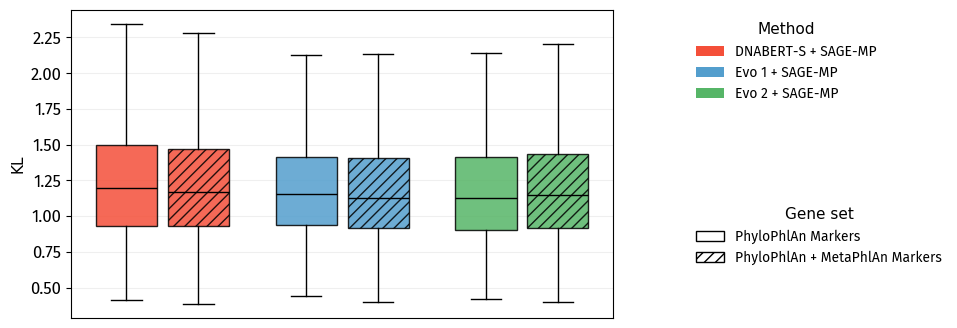

In [53]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

METHOD_COLORS = {
    'dnabert-s__epc_pool': sb.color_palette('Reds', n_colors=6)[3],
    'evo-1-8k-base_hyena5__epc_pool': sb.color_palette('Blues', n_colors=6)[3],
    'evo2_7b_hyena10__epc_pool': sb.color_palette('Greens', n_colors=6)[3],
}

METHOD_NAMES = {
    "dnabert-s__epc_pool": "DNABERT-S + SAGE-MP",
    "evo-1-8k-base_hyena5__epc_pool": "Evo 1 + SAGE-MP",
    "evo2_7b_hyena10__epc_pool": "Evo 2 + SAGE-MP",
}

GENESET_DISPLAY_NAMES = {
    "phylophlan":            "PhyloPhlAn Markers",
    "phylophlan_metaphlan":  "PhyloPhlAn + MetaPhlAn Markers",
}

HATCH_PATTERNS = {
    "phylophlan":            "",
    "phylophlan_metaphlan":  "///",
}

methods   = sorted(pcoa_result_df["PredictionMethod"].unique())
print(methods)
genesets  = sorted(pcoa_result_df["GeneSet"].unique())

n_methods  = len(methods)
n_genesets = len(genesets)

group_width  = 0.8
box_width    = group_width / n_genesets
offsets      = np.linspace(
    -group_width / 2 + box_width / 2,
     group_width / 2 - box_width / 2,
    n_genesets
)

width = 10
height = 4
fig, axes = plt.subplots(1, 2, figsize=(width, height), width_ratios=[1, 0.3])
plot_ax = axes[0]
legend_ax = axes[1]

for i, method in enumerate(methods):
    color = METHOD_COLORS.get(method, "#888780")
    for j, geneset in enumerate(genesets):
        subset = pcoa_result_df[(pcoa_result_df["PredictionMethod"] == method) & (pcoa_result_df["GeneSet"] == geneset)]["KL_err"]
        if subset.empty:
            continue

        pos    = i + offsets[j]
        hatch  = HATCH_PATTERNS.get(geneset, "")

        bp = plot_ax.boxplot(
            subset,
            positions=[pos],
            widths=box_width * 0.85,
            patch_artist=True,
            manage_ticks=False,
            showfliers=False,
            # flierprops=dict(marker="o", markersize=3,
            #                 markerfacecolor=color, markeredgecolor=color,
            #                 alpha=0.5),
            medianprops=dict(color="black", linewidth=1),
            # whiskerprops=dict(color=color, linewidth=1),
            # capprops=dict(color=color, linewidth=1),
            # boxprops=dict(linewidth=1),
        )

        for patch in bp["boxes"]:
            patch.set_facecolor(color)
            patch.set_alpha(0.85)
            patch.set_hatch(hatch)
            # patch.set_edgecolor(color)

plot_ax.set_xticks([])
# plot_ax.set_xticklabels([METHOD_NAMES[m] for m in methods], rotation=0, ha="center", fontsize=10)
plot_ax.set_ylabel("KL", fontsize=11)
# plot_ax.set_xlabel("Method", fontsize=11)

# Legend for methods (color)
method_handles = [
    mpatches.Patch(facecolor=METHOD_COLORS.get(m, "#888780"), label=METHOD_NAMES[m])
    for m in methods
]

# Legend for gene sets (hatch)
geneset_handles = [
    mpatches.Patch(
        facecolor="white",
        edgecolor="black",
        hatch=HATCH_PATTERNS.get(g, ""),
        label=GENESET_DISPLAY_NAMES[g]
    )
    for g in genesets
]

legend_ax.set_axis_off()
leg1 = legend_ax.legend(handles=method_handles,  title="Method",
                 loc="upper left", bbox_to_anchor=(0, 1),
                 prop={'family': 'Fira Sans', 'weight': 'normal'},
                 fontsize=LEGEND_FONT_SIZE, title_fontsize=LEGEND_FONT_SIZE+1, frameon=False)
legend_ax.add_artist(leg1)
legend_ax.legend(
    handles=geneset_handles, title="Gene set",
    loc="upper left", bbox_to_anchor=(0, 0.4),
    prop={'family': 'Fira Sans', 'weight': 'normal'},
    fontsize=LEGEND_FONT_SIZE, title_fontsize=LEGEND_FONT_SIZE+1, frameon=False)

# plot_ax.spines[["top", "right"]].set_visible(False)
plot_ax.grid(axis="y", linestyle="-", alpha=0.2)

from matplotlib.font_manager import FontProperties
custom_font = FontProperties(family='Fira Sans', weight='normal', size=FONT_SIZE)
for ax in [plot_ax, legend_ax]:
    for label in ax.get_xticklabels():
        label.set_fontproperties(custom_font)
    for label in ax.get_yticklabels():
        label.set_fontproperties(custom_font)
    ax.grid(axis="y", linestyle="-", alpha=0.2)


plt.savefig("results/sgb_extended_gene_set.pdf", bbox_inches='tight', transparent=True)
plt.savefig("results/sgb_extended_gene_set.png", dpi=800, bbox_inches='tight', transparent=True)
print("done")